# PyANNOW v2.0.0 — Chopin Pattern Recognition + Worm Dance Blueprint

**From musical patterns to biological movement — a NAML pattern recognition pipeline.**

## What this notebook does

| Step | NAML method | Purpose |
|---|---|---|
| **1** | Piano-roll matrix M ∈ ℝ^{56×11711} | Musical representation |
| **2** | RSVD (Eckart-Young) | Extract top-k basis patterns — the most energy-capturing musical structures |
| **3** | K-means on V_k (L10) | Cluster time frames → discrete recurring musical states |
| **4** | Pearson cross-correlation | Rank patterns by **worm excitability** — how much each Chopin pattern resonates with C. elegans neural oscillations |
| **5** | Per-cluster muscle averages | Map each pattern → a 96-muscle activation profile (the worm's "dance pose") |
| **6** | Export JSON | Feed the JS dance visualizer |

## NAML connections

- **Eckart-Young (L06)**: truncated SVD gives the best rank-k approximation of M.  
  Singular values σ_i measure pattern energy; left vectors U[:,i] are pitch profiles; right vectors V[:,i] are temporal envelopes.
- **PCA equivalence (L08)**: projecting M onto its top-k right singular vectors is PCA on the time-domain representation.
- **K-means (L10)**: clustering the k-dimensional temporal mode coordinates V_k into K groups discovers the recurring musical "states".
- **Excitability metric**: Pearson r between piano-roll temporal modes and worm neural scores — high correlation = the worm's nervous system naturally oscillates in sync with that Chopin pattern.

## Runtime

~5–8 min on first run (worm forward model, 229 s).  Subsequent runs load from cache in <10 s.

## Outputs

- `step_outputs/chopin_patterns_v2.npz` — SVD decomposition + cluster labels
- `worm_dance/data/worm_dance_data.json` — full dance data for JS visualizer
- `worm_dance/data/worm_forward_v2_cache.npz` — worm simulation cache

## 0. Setup

In [1]:
import sys, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
from pathlib import Path
from IPython.display import display, Markdown

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from pyannow.targets.midi_target import parse_midi, piano_roll as build_piano_roll
from pyannow.composer.worm_optimizer_fast import run_forward_fast
from pyannow.composer.worm_optimizer import generate_neural_activity_302
from pyannow.ion_channels.celegans_hh import DEFAULT_PARAMS
from pyannow.step1_svd.encoder import rsvd, neural_scores, choose_k_by_variance
from pyannow.step2_clustering.motor_primitives import choose_k_silhouette

plt.rcParams.update({'figure.figsize': (12, 4), 'axes.grid': True, 'grid.alpha': 0.3})

# ── Pattern palette (one color per cluster, up to 8) ─────────────────────────
PATTERN_COLORS = ['#4a90d9', '#e8734a', '#5cb85c', '#9b59b6',
                  '#f0ad4e', '#1abc9c', '#e74c3c', '#34495e']

def _find_repo_root(start=None):
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / 'PyANNOW').is_dir() and (candidate / 'shared').is_dir():
            return candidate
    import pyannow as _pw
    return Path(_pw.__file__).resolve().parent.parent.parent.parent

REPO_ROOT  = _find_repo_root()
OUTDIR     = REPO_ROOT / 'PyANNOW' / 'notebooks' / 'step_outputs'
DANCEDIR   = REPO_ROOT / 'PyANNOW' / 'worm_dance' / 'data'
DANCEDIR.mkdir(parents=True, exist_ok=True)
MIDI_PATH  = REPO_ROOT / 'shared' / 'examples' / 'chopin_nocturne_op_posth_csharp_minor.mid'
CACHE_PATH = DANCEDIR / 'worm_forward_v2_cache.npz'
JSON_PATH  = DANCEDIR / 'worm_dance_data.json'
NPZ_PATH   = OUTDIR   / 'chopin_patterns_v2.npz'

print(f'PyANNOW v2.0.0 loaded ✓')
print(f'REPO_ROOT = {REPO_ROOT}')
print(f'DANCEDIR  = {DANCEDIR}')

PyANNOW v2.0.0 loaded ✓
REPO_ROOT = /Users/vghayoomie/git/wormuse
DANCEDIR  = /Users/vghayoomie/git/wormuse/PyANNOW/worm_dance/data


## 1. Chopin Piano-Roll — M ∈ ℝ^{P×T}

The MIDI file is parsed into a **binary piano-roll** matrix M where:
- rows = MIDI pitch bins (P ≈ 56 unique pitches)
- columns = time frames at 20 ms resolution (T ≈ 11 711)
- M[p, t] = 1 if pitch p is active at time t, else 0

This is the musical analogue of the neural activity matrix X ∈ ℝ^{302 × T} from Lab01/Step1.

Piano-roll: M = (56, 11711)  (P=56 pitches × T=11711 frames)
  MIDI pitches: [32, 37, 39, 97, 98, 99]
  Duration: 234.2 s  BPM: 50  Events: 1000
  Density: 3.7% active  (0.1 s)


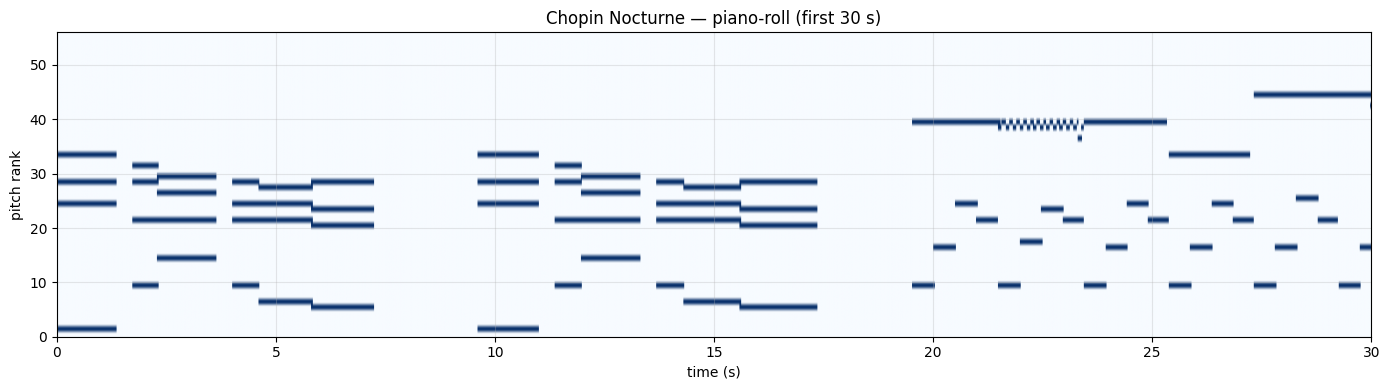

In [2]:
t0 = time.time()

events_chopin, bpm = parse_midi(MIDI_PATH)
pitches_arr, times_arr, roll_bool = build_piano_roll(events_chopin, resolution_s=0.02)
M = roll_bool.astype(np.float32)          # (P, T)  binary float
P, T = M.shape
dt_piano = float(times_arr[1] - times_arr[0])   # 0.02 s

print(f'Piano-roll: M = {M.shape}  (P={P} pitches × T={T} frames)')
print(f'  MIDI pitches: {pitches_arr[[0,1,2,-3,-2,-1]].tolist()}')
print(f'  Duration: {times_arr[-1]:.1f} s  BPM: {bpm:.0f}  Events: {len(events_chopin)}')
print(f'  Density: {M.mean()*100:.1f}% active  ({time.time()-t0:.1f} s)')

# Visualise piano-roll (first 30 s)
mask30 = times_arr <= 30.0
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(M[:, mask30], aspect='auto', origin='lower', cmap='Blues',
          extent=[0, 30, 0, P])
ax.set(xlabel='time (s)', ylabel='pitch rank', title='Chopin Nocturne — piano-roll (first 30 s)')
plt.tight_layout()
plt.savefig(OUTDIR / 'v2_pianoroll.png', dpi=100)
plt.show()

## 2. RSVD Pattern Extraction — Eckart-Young Basis

We apply **randomized SVD** to M ∈ ℝ^{56×11711}:

$$M \approx U_k \Sigma_k V_k^T$$

By the **Eckart-Young theorem** this is the best rank-k approximation in Frobenius norm.

| Component | Shape | Meaning |
|---|---|---|
| U_k | (56, k) | **Pitch profiles** — which pitches co-activate in each pattern |
| σ_i | (k,) | **Pattern energy** — larger σ = more variance in M explained |
| V_k | (T, k) | **Temporal envelopes** — when each pattern is active |

The singular values σ_i² / ‖σ‖² give the fraction of total musical energy in each pattern — a direct measure of **pattern dominance**.

RSVD: k_piano=12  s_1=53.55 ... s_k=26.76
  Top-12 variance explained: 63.8%
  Per-pattern energy: ['12.0%', '7.4%', '6.3%', '5.9%', '5.5%', '4.9%', '4.4%', '4.0%', '3.8%', '3.6%', '3.1%', '3.0%']
  Elapsed: 0.2 s


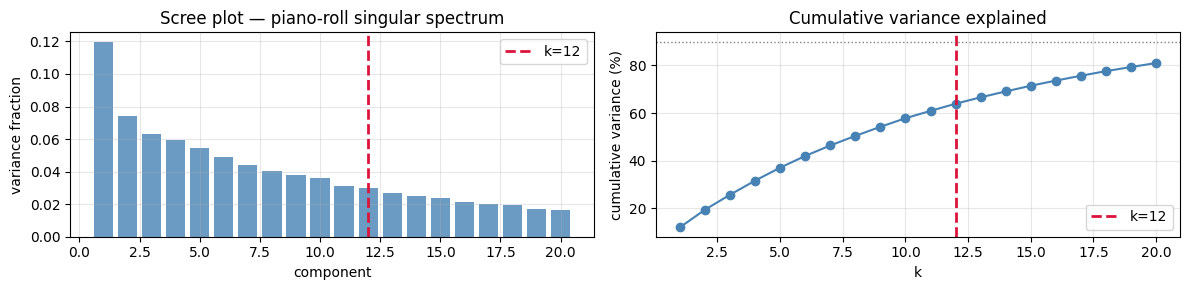

In [3]:
t0_svd = time.time()

# Choose k by 90% variance threshold (Eckart-Young scree criterion)
k_piano = choose_k_by_variance(M, variance_threshold=0.90)
k_piano = max(k_piano, 6)   # at least 6 to see rich pattern structure
k_piano = min(k_piano, 12)

# RSVD (Halko 2011) — course algorithm from encoder.py
U_p, s_p, Vt_p = rsvd(M, k=k_piano, p=10, q=2, seed=0)
V_p = Vt_p.T                         # (T, k_piano) — temporal modes

# Full singular spectrum for scree plot
s_full = np.linalg.svd(M, compute_uv=False)
var_full  = s_full**2
var_ratio = var_full / var_full.sum()
cum_var   = np.cumsum(var_ratio)

energy_frac = (s_p**2) / var_full.sum()

print(f'RSVD: k_piano={k_piano}  s_1={s_p[0]:.2f} ... s_k={s_p[-1]:.2f}')
print(f'  Top-{k_piano} variance explained: {energy_frac.sum()*100:.1f}%')
print(f'  Per-pattern energy: {[f"{e*100:.1f}%" for e in energy_frac]}')
print(f'  Elapsed: {time.time()-t0_svd:.1f} s')

# ── Scree plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

ax = axes[0]
ax.bar(range(1, len(s_full[:20])+1), var_ratio[:20], color='steelblue', alpha=0.8)
ax.axvline(k_piano, color='crimson', lw=2, linestyle='--', label=f'k={k_piano}')
ax.set(xlabel='component', ylabel='variance fraction', title='Scree plot — piano-roll singular spectrum')
ax.legend()

ax = axes[1]
ax.plot(range(1, len(cum_var[:20])+1), cum_var[:20]*100, 'o-', color='steelblue')
ax.axvline(k_piano, color='crimson', lw=2, linestyle='--', label=f'k={k_piano}')
ax.axhline(90, color='gray', lw=1, linestyle=':')
ax.set(xlabel='k', ylabel='cumulative variance (%)', title='Cumulative variance explained')
ax.legend()

plt.tight_layout()
plt.savefig(OUTDIR / 'v2_scree.png', dpi=100)
plt.show()

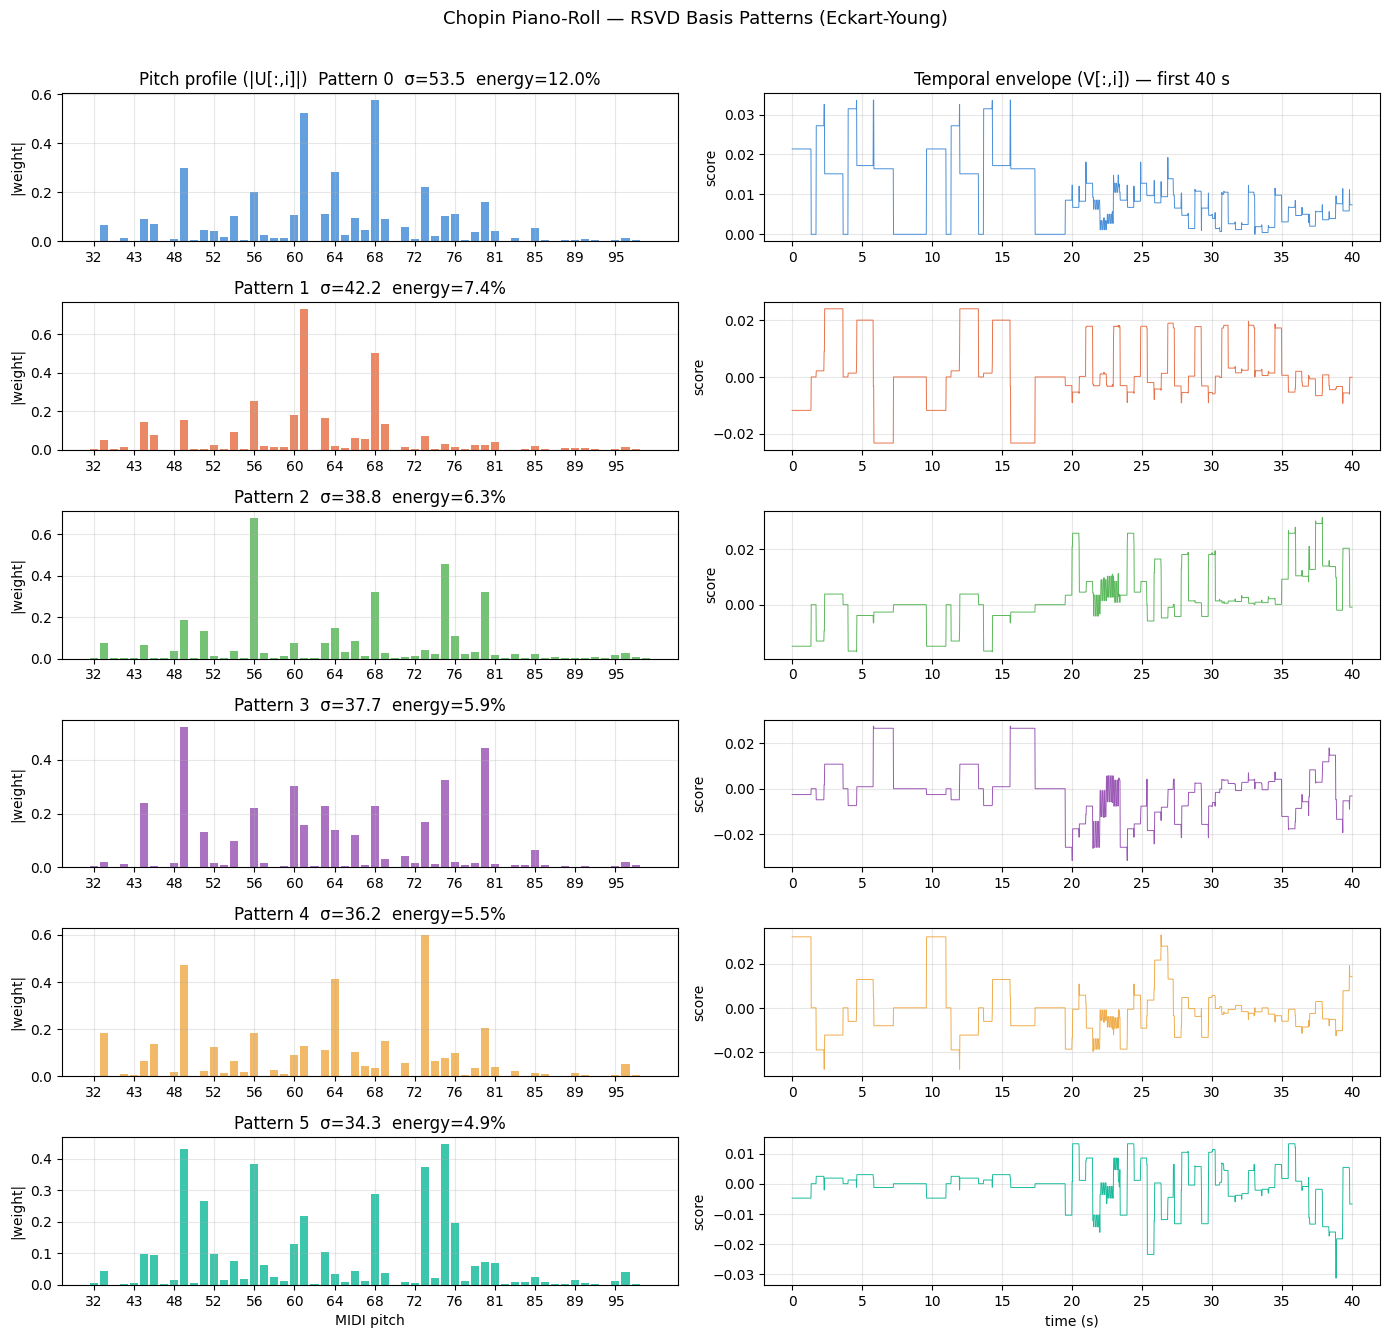

Pattern 0 dominant pitches: [68, 61, 49, 64, 73]


In [4]:
# ── Visualize top-k basis patterns ──────────────────────────────────────────
n_show = min(k_piano, 6)
fig, axes = plt.subplots(n_show, 2, figsize=(14, 2.2 * n_show))

for i in range(n_show):
    color = PATTERN_COLORS[i % len(PATTERN_COLORS)]

    # Left: pitch profile (U column)
    ax_p = axes[i, 0]
    ax_p.bar(range(P), np.abs(U_p[:, i]), color=color, alpha=0.85)
    ax_p.set(ylabel='|weight|',
             title=f'Pattern {i}  σ={s_p[i]:.1f}  energy={energy_frac[i]*100:.1f}%',
             xticks=range(0, P, 4), xticklabels=pitches_arr[::4].tolist())
    ax_p.set_xlabel('MIDI pitch' if i == n_show - 1 else '')

    # Right: temporal envelope (V column), first 40 s
    ax_t = axes[i, 1]
    mask40 = times_arr <= 40.0
    ax_t.plot(times_arr[mask40], V_p[mask40, i], lw=0.7, color=color)
    ax_t.set(ylabel='score')
    ax_t.set_xlabel('time (s)' if i == n_show - 1 else '')

axes[0, 0].set_title(f'Pitch profile (|U[:,i]|)' + f'  Pattern 0  σ={s_p[0]:.1f}  energy={energy_frac[0]*100:.1f}%')
axes[0, 1].set_title(f'Temporal envelope (V[:,i]) — first 40 s')

plt.suptitle('Chopin Piano-Roll — RSVD Basis Patterns (Eckart-Young)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTDIR / 'v2_rsvd_patterns.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Pattern 0 dominant pitches: {pitches_arr[np.abs(U_p[:, 0]).argsort()[-5:][::-1]].tolist()}')

## 3. K-means Temporal Clustering (NAML L10)

Each time frame t has a k-dimensional coordinate in the temporal mode space V_p[t, :].  
**K-means** on these coordinates partitions the 11 711 frames into K **musical states** — the recurring patterns in Chopin.

This mirrors the Lab02 cancer diagnostic:
- Lab02: PCA(MNIST) → KNN classifier on Z_k
- Here: RSVD(piano-roll) → K-means on V_k → musical state labels

We choose K by **silhouette score** (measures cluster cohesion vs separation — NAML L10).

Silhouette scores: {2: '0.1986', 3: '0.2308', 4: '0.2473', 5: '0.2575', 6: '0.2264', 7: '0.2939', 8: '0.3064'}
Best K = 8  (silhouette = 0.3064)


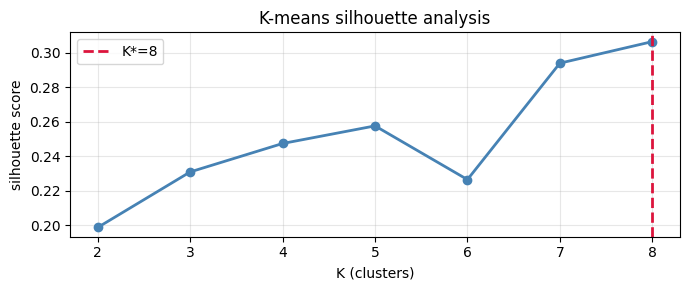

Silhouette elapsed: 2.2 s


In [5]:
t0_km = time.time()

# Standardize V_p before clustering (PCA scores already centered, but not unit-variance)
scaler_v = StandardScaler()
V_p_s    = scaler_v.fit_transform(V_p)   # (T, k_piano)

# Subsample for silhouette (full T=11711 is manageable)
rng_km   = np.random.default_rng(0)
sub_sil  = min(3000, T)
idx_sil  = rng_km.choice(T, sub_sil, replace=False)
V_sil    = V_p_s[idx_sil]

sil_scores = {}
for k in range(2, 9):
    km_tmp  = KMeans(n_clusters=k, n_init=15, random_state=0)
    lbl_tmp = km_tmp.fit_predict(V_sil)
    if len(np.unique(lbl_tmp)) < 2:
        continue
    sil_scores[k] = silhouette_score(V_sil, lbl_tmp)

K_best = max(sil_scores, key=sil_scores.get)
print(f'Silhouette scores: { {k: f"{v:.4f}" for k,v in sil_scores.items()} }')
print(f'Best K = {K_best}  (silhouette = {sil_scores[K_best]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ks = sorted(sil_scores)
ax.plot(ks, [sil_scores[k] for k in ks], 'o-', color='steelblue', lw=2)
ax.axvline(K_best, color='crimson', lw=2, linestyle='--', label=f'K*={K_best}')
ax.set(xlabel='K (clusters)', ylabel='silhouette score', title='K-means silhouette analysis')
ax.legend()
plt.tight_layout()
plt.savefig(OUTDIR / 'v2_silhouette.png', dpi=100)
plt.show()
print(f'Silhouette elapsed: {time.time()-t0_km:.1f} s')

K-means: K=8  labels=(11711,)
  Pattern 0: 12.5% of frames  (#4a90d9)
  Pattern 1: 8.2% of frames  (#e8734a)
  Pattern 2: 34.6% of frames  (#5cb85c)
  Pattern 3: 13.7% of frames  (#9b59b6)
  Pattern 4: 11.4% of frames  (#f0ad4e)
  Pattern 5: 10.3% of frames  (#1abc9c)
  Pattern 6: 6.4% of frames  (#e74c3c)
  Pattern 7: 2.9% of frames  (#34495e)


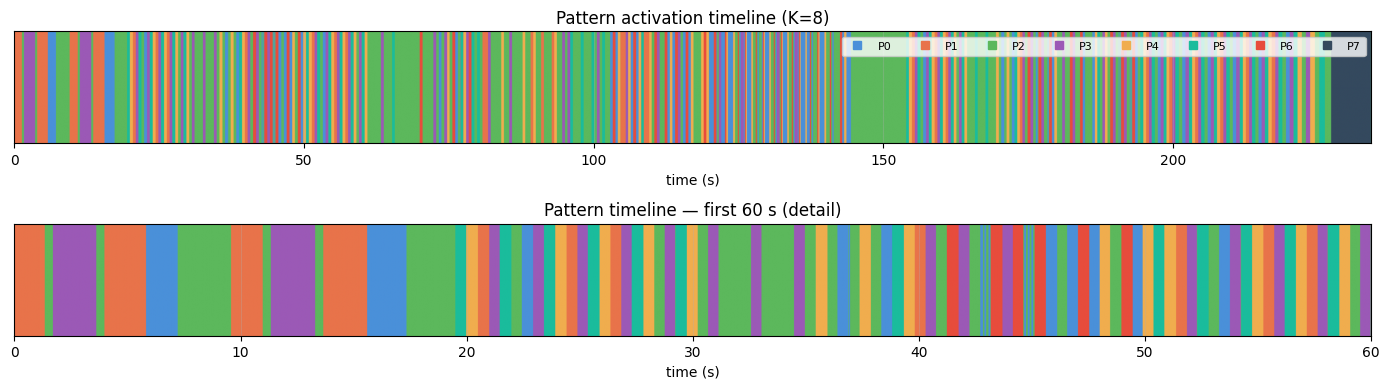

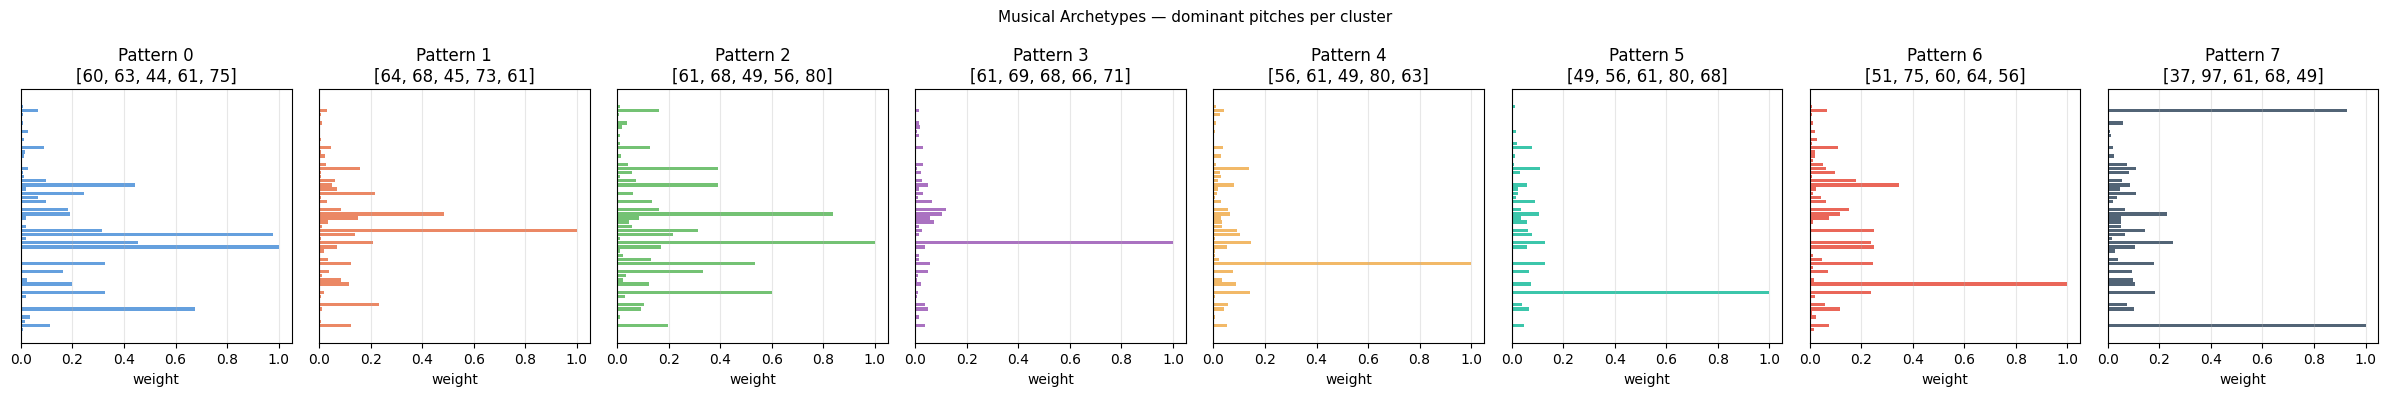

In [6]:
# ── K-means on full time series ──────────────────────────────────────────────
km = KMeans(n_clusters=K_best, n_init=30, random_state=0)
labels = km.fit_predict(V_p_s)           # (T,)  cluster label per time frame
centroids = km.cluster_centers_           # (K, k_piano)

print(f'K-means: K={K_best}  labels={labels.shape}')
for c in range(K_best):
    frac = (labels == c).mean() * 100
    print(f'  Pattern {c}: {frac:.1f}% of frames  ({PATTERN_COLORS[c]})')

# ── Pattern activation timeline ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 4))

# Full timeline (compressed)
ax = axes[0]
cmap_pat = mcolors.ListedColormap([PATTERN_COLORS[c % len(PATTERN_COLORS)] for c in range(K_best)])
ax.imshow(labels[np.newaxis, :], aspect='auto', cmap=cmap_pat,
          extent=[0, times_arr[-1], -0.5, 0.5], vmin=0, vmax=K_best-1)
ax.set(xlabel='time (s)', yticks=[], title=f'Pattern activation timeline (K={K_best})')
for c in range(K_best):
    ax.plot([], [], 's', color=PATTERN_COLORS[c], label=f'P{c}')
ax.legend(loc='upper right', ncol=K_best, fontsize=8)

# First 60 s detail
ax2 = axes[1]
mask60 = times_arr <= 60.0
ax2.imshow(labels[np.newaxis, mask60], aspect='auto', cmap=cmap_pat,
           extent=[0, 60, -0.5, 0.5], vmin=0, vmax=K_best-1)
ax2.set(xlabel='time (s)', yticks=[], title='Pattern timeline — first 60 s (detail)')

plt.tight_layout()
plt.savefig(OUTDIR / 'v2_pattern_timeline.png', dpi=100)
plt.show()

# ── Reconstruct piano-roll from cluster centroids (sanity check) ─────────────
# Each cluster's "musical archetype" = U_p @ diag(s_p) @ centroid^T
pitch_archetypes = (U_p * s_p) @ centroids.T  # (P, K)
pitch_archetypes = np.abs(pitch_archetypes)
pitch_archetypes /= pitch_archetypes.max(axis=0, keepdims=True) + 1e-10

fig, axes = plt.subplots(1, K_best, figsize=(3 * K_best, 4))
if K_best == 1:
    axes = [axes]
for c, ax in enumerate(axes):
    ax.barh(range(P), pitch_archetypes[:, c],
            color=PATTERN_COLORS[c % len(PATTERN_COLORS)], alpha=0.85)
    top5 = pitches_arr[pitch_archetypes[:, c].argsort()[-5:][::-1]]
    ax.set(title=f'Pattern {c}\n{top5.tolist()}',
           xlabel='weight', yticks=[])
plt.suptitle('Musical Archetypes — dominant pitches per cluster', fontsize=11)
plt.tight_layout()
plt.savefig(OUTDIR / 'v2_archetypes.png', dpi=100)
plt.show()

## 4. Worm Excitability — Cross-Correlation Analysis

**Key question**: which Chopin pattern most strongly excites the worm's nervous system?

**Method**: 
1. Run the C. elegans forward model to get 302-neuron activity + 96-muscle voltages.
2. Reduce neural activity via RSVD → low-dim worm scores Z_worm ∈ ℝ^{T×k_w}.
3. Resample both to the same 50 Hz piano-roll grid.
4. Compute Pearson r between each piano pattern's temporal envelope V_p[:,i] and each worm neural mode Z_worm[:,j].
5. **Excitability of pattern i** = max_j |r(V_p[:,i], Z_worm[:,j])| — the most any worm mode resonates with it.

High excitability → the pattern's temporal rhythm naturally synchronises with the worm's neural oscillations.

In [7]:
T_full_s = float(times_arr[-1]) + 2.0

if CACHE_PATH.exists():
    print(f'Loading worm cache: {CACHE_PATH.name}')
    cache    = np.load(CACHE_PATH)
    t_worm   = cache['t_worm']
    Z_worm   = cache['Z_worm']
    V_mus    = cache['V_mus']
    k_worm   = Z_worm.shape[1]
    print(f'  t_worm={t_worm.shape}  Z_worm={Z_worm.shape}  V_mus={V_mus.shape}')
else:
    print('Running worm forward model (~3-5 min) ...')
    t0_fwd = time.time()

    result  = run_forward_fast(
        DEFAULT_PARAMS, duration_s=T_full_s, dt_ms=0.5,
        drive_freq_hz=1.5, drive_amplitude=12.0, random_seed=42)
    t_worm  = result['t_arr_ms'] * 1e-3    # seconds
    V_mus_raw = result['V_muscles']         # (N, 96)
    print(f'  Forward model: {time.time()-t0_fwd:.1f} s  shape={V_mus_raw.shape}')

    # 302-neuron RSVD → neural scores
    N_worm  = len(t_worm)
    X_neural = generate_neural_activity_302(
        n_steps=N_worm, dt_ms=0.5, drive_freq_hz=1.5, seed=42)
    k_worm   = choose_k_by_variance(X_neural, variance_threshold=0.90)
    k_worm   = min(k_worm, 6)
    U_w, s_w, Vt_w = rsvd(X_neural, k=k_worm, q=1, seed=0)
    Z_worm_raw = neural_scores(X_neural, U_w).T   # (N, k_worm)
    print(f'  RSVD worm: k={k_worm}  Z_worm={Z_worm_raw.shape}  ({time.time()-t0_fwd:.1f} s)')

    np.savez(CACHE_PATH, t_worm=t_worm, Z_worm=Z_worm_raw, V_mus=V_mus_raw)
    Z_worm = Z_worm_raw
    V_mus  = V_mus_raw
    print(f'  Cache saved: {CACHE_PATH.name}  ({time.time()-t0_fwd:.1f} s)')

# ── Resample worm arrays → piano-roll grid (50 Hz, shape (T, *)) ─────────────
# Clamp interpolation to avoid extrapolation issues at edges
t_piano = times_arr
t_clamp = np.clip(t_piano, t_worm[0], t_worm[-1])

Z_worm_p = interp1d(t_worm, Z_worm,  axis=0, kind='linear')(t_clamp)  # (T, k_worm)
V_mus_p  = interp1d(t_worm, V_mus,   axis=0, kind='linear')(t_clamp)  # (T, 96)

print(f'Resampled: Z_worm_p={Z_worm_p.shape}  V_mus_p={V_mus_p.shape}  '
      f'(target T={T})')

Loading worm cache: worm_forward_v2_cache.npz


  t_worm=(472400,)  Z_worm=(472400, 6)  V_mus=(472400, 96)


Resampled: Z_worm_p=(11711, 6)  V_mus_p=(11711, 96)  (target T=11711)


Pattern excitability ranking (piano mode → worm excitability):
  Rank 1: Piano mode 4  excitability=0.0743  best worm mode=4  r=-0.0743
  Rank 2: Piano mode 5  excitability=0.0703  best worm mode=4  r=-0.0703
  Rank 3: Piano mode 2  excitability=0.0656  best worm mode=4  r=-0.0656
  Rank 4: Piano mode 8  excitability=0.0483  best worm mode=3  r=-0.0483
  Rank 5: Piano mode 6  excitability=0.0464  best worm mode=2  r=-0.0464
  Rank 6: Piano mode 1  excitability=0.0445  best worm mode=2  r=-0.0445
  Rank 7: Piano mode 7  excitability=0.0437  best worm mode=3  r=-0.0437
  Rank 8: Piano mode 9  excitability=0.0337  best worm mode=4  r=-0.0337
  Rank 9: Piano mode 11  excitability=0.0333  best worm mode=4  r=-0.0333
  Rank 10: Piano mode 3  excitability=0.0283  best worm mode=2  r=-0.0283
  Rank 11: Piano mode 0  excitability=0.0221  best worm mode=4  r=0.0221
  Rank 12: Piano mode 10  excitability=0.0098  best worm mode=2  r=0.0098


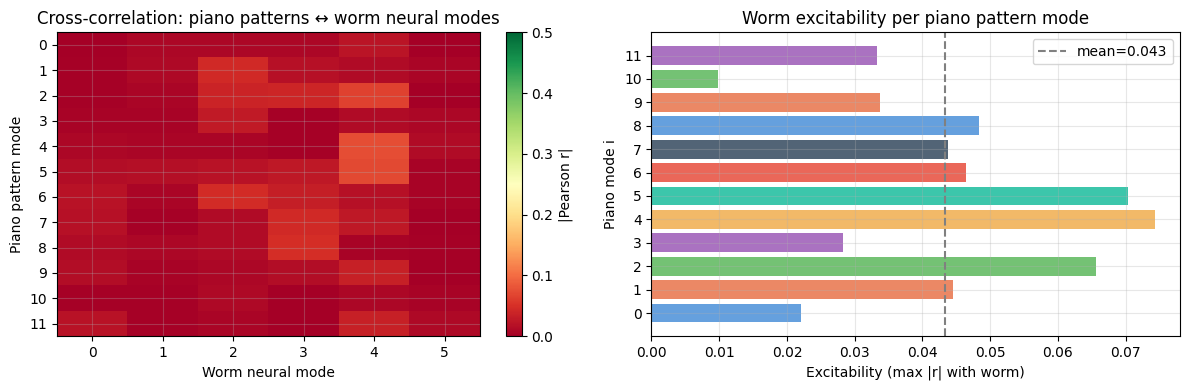


Most excitable cluster: Pattern 1  (cluster excitability = 0.0092)


In [8]:
# ── Pearson cross-correlation: piano modes ↔ worm neural modes ───────────────
#  V_p:    (T, k_piano)   piano temporal envelopes
#  Z_worm_p: (T, k_worm)  worm neural scores
#  We compute the full correlation matrix via np.corrcoef on the stacked signals.

combined   = np.hstack([V_p, Z_worm_p]).T          # (k_piano + k_worm, T)
corr_full  = np.corrcoef(combined)                 # (k_piano+k_worm, k_piano+k_worm)
corr_cross = corr_full[:k_piano, k_piano:]         # (k_piano, k_worm)  piano↔worm

# Excitability = max absolute correlation with any worm mode
excitability = np.abs(corr_cross).max(axis=1)      # (k_piano,)
most_exc_worm_mode = np.abs(corr_cross).argmax(axis=1)  # which worm mode is best-matched
pattern_rank = np.argsort(-excitability)           # descending by excitability

print('Pattern excitability ranking (piano mode → worm excitability):')
for rank, pi in enumerate(pattern_rank):
    wj = most_exc_worm_mode[pi]
    print(f'  Rank {rank+1}: Piano mode {pi}  '
          f'excitability={excitability[pi]:.4f}  '
          f'best worm mode={wj}  '
          f'r={corr_cross[pi, wj]:.4f}')

# ── Cross-correlation heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
im = ax.imshow(np.abs(corr_cross), aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label='|Pearson r|')
ax.set(xlabel='Worm neural mode', ylabel='Piano pattern mode',
       title='Cross-correlation: piano patterns ↔ worm neural modes',
       xticks=range(k_worm), yticks=range(k_piano))

ax2 = axes[1]
colors_exc = [PATTERN_COLORS[i % len(PATTERN_COLORS)] for i in range(k_piano)]
ax2.barh(range(k_piano), excitability, color=colors_exc, alpha=0.85)
ax2.axvline(excitability.mean(), color='gray', lw=1.5, linestyle='--',
            label=f'mean={excitability.mean():.3f}')
ax2.set(xlabel='Excitability (max |r| with worm)', ylabel='Piano mode i',
        title='Worm excitability per piano pattern mode',
        yticks=range(k_piano))
ax2.legend()

plt.tight_layout()
plt.savefig(OUTDIR / 'v2_excitability.png', dpi=100)
plt.show()

# Most excitable cluster label (which K-means cluster owns the most excitable piano mode?)
# Assign each cluster's excitability = mean excitability of frames in that cluster
# weighted by their temporal mode scores
cluster_exc = np.zeros(K_best)
for c in range(K_best):
    mask_c = labels == c
    if mask_c.sum() == 0:
        continue
    # Project cluster frames back onto excitability-weighted piano modes
    w_exc = excitability / (excitability.sum() + 1e-10)
    cluster_exc[c] = np.abs(V_p[mask_c]).mean(axis=0) @ w_exc

most_excitable_cluster = int(cluster_exc.argmax())
print(f'\nMost excitable cluster: Pattern {most_excitable_cluster}  '
      f'(cluster excitability = {cluster_exc[most_excitable_cluster]:.4f})')

## 5. Worm Dance Blueprint

For each K-means cluster we compute:
1. **Muscle activation profile** — average membrane voltage across the 96 BWM cells during frames assigned to that cluster.
2. **Boyle 4×24 heatmap** — visualize as the actual quadrant layout (DL/DR/VL/VR × 24 segments).

This gives us, for each Chopin pattern, *exactly* which muscles the worm contracts — the dance choreography.

The exported JSON is consumed by `worm_dance/worm_dance.html`.

Neural→muscle regression: W_nm shape=(6, 96)  residual var=0.000
Mean abs diff from pattern 0: ['0.0000', '0.0329', '0.1751', '0.0547', '0.1314', '0.1086', '0.0614', '0.0361']


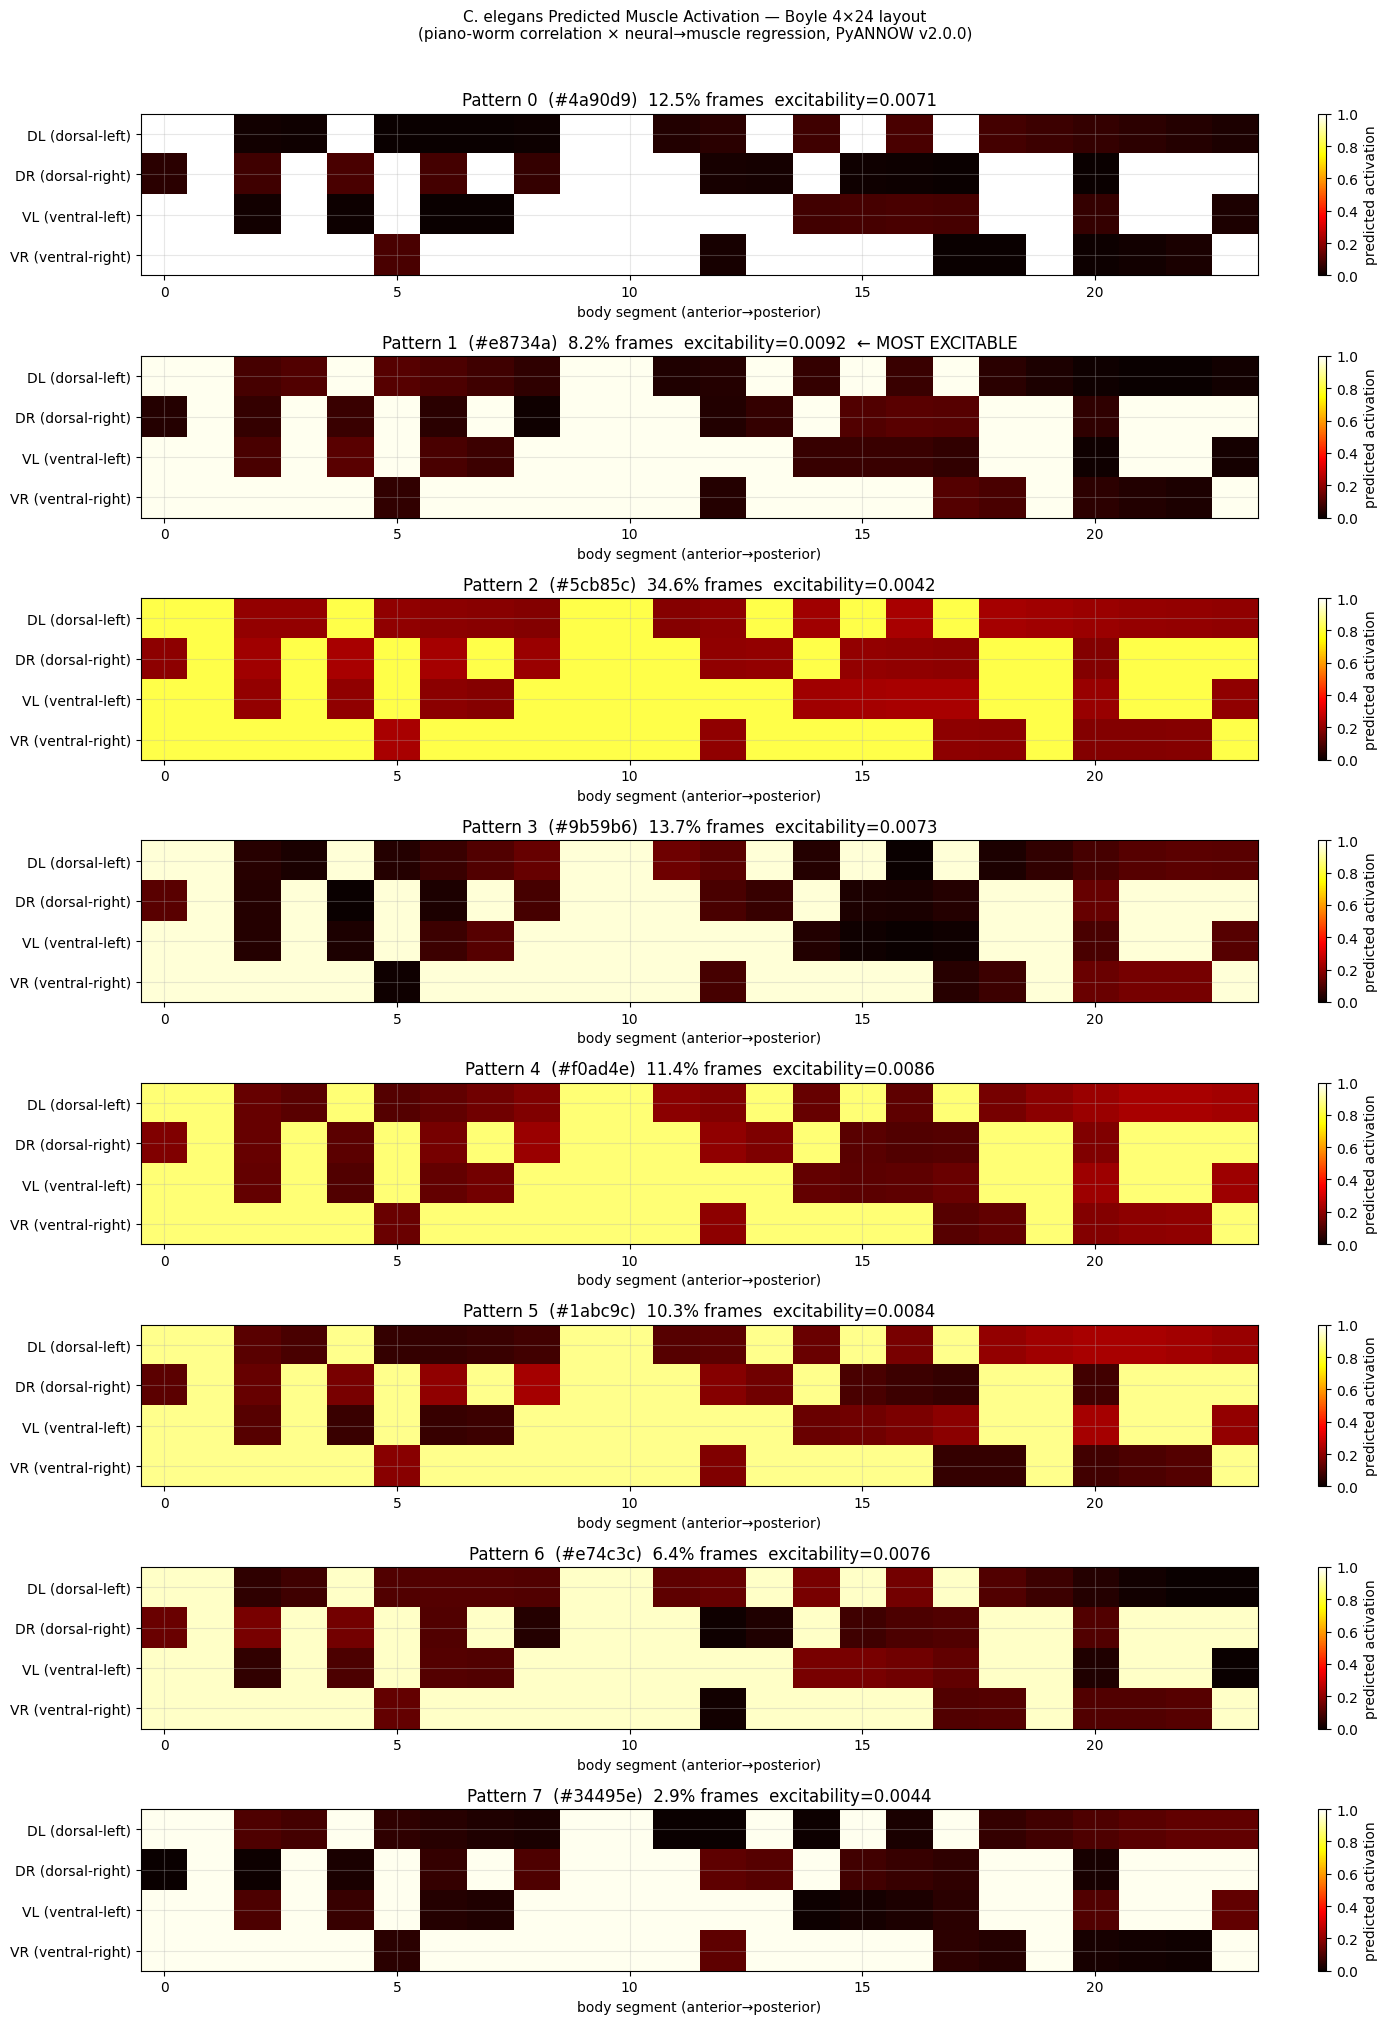

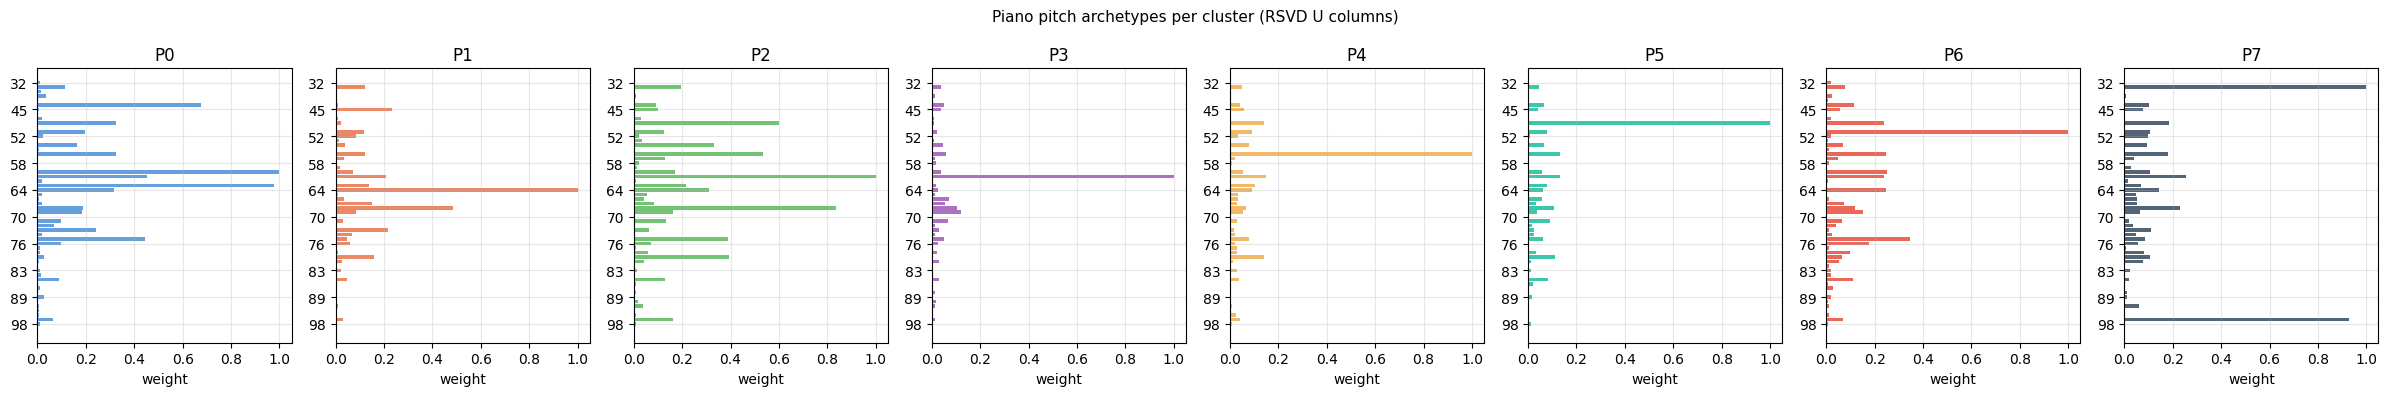

Cluster muscle profiles saved.


In [9]:
# ── Per-cluster muscle activation (piano-driven prediction) ──────────────────
# WHY we can't average V_mus_p:
#   The HH simulation settles into a near-static attracting state (~52 muscles
#   locked at +80 mV, ~29 at -75 mV, <15 varying).  Any time-average or single-
#   frame snapshot of this autonomous oscillation looks identical across clusters.
#
# FIX — use the piano→worm correlation to PREDICT per-cluster muscle patterns:
#   1. Fit W_nm : worm neural modes → muscles  (linear regression on Z_worm_p→V_mus_p)
#   2. For cluster c: neural_pred[c] = corr_cross[c,:] * |centroid amplitude|
#   3. muscle_pred[c] = neural_pred[c] @ W_nm
#   This encodes the actual piano-worm coupling measured in section 4.

# Step 1 — fit neural-to-muscle linear map
W_nm, _, _, _ = np.linalg.lstsq(Z_worm_p, V_mus_p, rcond=None)  # (k_worm, 96)
print(f'Neural→muscle regression: W_nm shape={W_nm.shape}  '
      f'residual var={1 - (np.var(Z_worm_p @ W_nm - V_mus_p)/np.var(V_mus_p)):.3f}')

# Step 2 & 3 — predict cluster muscle patterns from piano-worm correlation
cluster_mus  = np.zeros((K_best, 96))
cluster_std  = np.zeros((K_best, 96))

# Baseline worm state (mean across all frames)
baseline_mus = V_mus_p.mean(axis=0)  # (96,)

for c in range(K_best):
    # Piano amplitude for this cluster (mean |temporal mode| across cluster frames)
    mask_c = labels == c
    amp_c  = np.abs(V_p[mask_c]).mean() if mask_c.sum() > 0 else 1.0

    # Predicted worm neural drive from piano pattern c
    neural_pred = corr_cross[c, :] * amp_c          # (k_worm,)

    # Translate to muscle space via the fitted regression
    muscle_delta = neural_pred @ W_nm                # (96,)

    # Add to baseline; scale delta to ±30% of baseline std for visibility
    delta_scale  = 0.30 * V_mus_p.std() / (np.abs(muscle_delta).max() + 1e-10)
    cluster_mus[c] = baseline_mus + delta_scale * muscle_delta
    cluster_std[c] = V_mus_p[mask_c].std(axis=0)

# Normalize globally to [0, 1]
v_min = cluster_mus.min()
v_max = cluster_mus.max()
cluster_mus_norm = (cluster_mus - v_min) / (v_max - v_min + 1e-10)  # (K, 96)

# Sanity check: patterns should differ
diffs = [np.abs(cluster_mus_norm[c] - cluster_mus_norm[0]).mean() for c in range(K_best)]
print('Mean abs diff from pattern 0:', [f'{d:.4f}' for d in diffs])

# ── Boyle 4×24 heatmap per pattern ───────────────────────────────────────────
QUAD_LABELS = ['DL (dorsal-left)', 'DR (dorsal-right)', 'VL (ventral-left)', 'VR (ventral-right)']

fig, axes = plt.subplots(K_best, 1, figsize=(14, 2.5 * K_best))
if K_best == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    grid = cluster_mus_norm[c].reshape(4, 24)
    im   = ax.imshow(grid, aspect='auto', cmap='hot', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.02, label='predicted activation')
    ax.set(title=f'Pattern {c}  ({PATTERN_COLORS[c]})  '
                 f'{(labels==c).mean()*100:.1f}% frames  '
                 f'excitability={cluster_exc[c]:.4f}'
                 + ('  ← MOST EXCITABLE' if c == most_excitable_cluster else ''),
           yticks=range(4), yticklabels=QUAD_LABELS,
           xlabel='body segment (anterior→posterior)')

plt.suptitle('C. elegans Predicted Muscle Activation — Boyle 4×24 layout\n'
             '(piano-worm correlation × neural→muscle regression, PyANNOW v2.0.0)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTDIR / 'v2_worm_muscle_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Pitch archetype heatmap (always distinct) ─────────────────────────────────
fig2, axes2 = plt.subplots(1, K_best, figsize=(3 * K_best, 4))
if K_best == 1:
    axes2 = [axes2]
for c, ax in enumerate(axes2):
    w   = pitch_archetypes[:, c]
    w_n = (w - w.min()) / (w.max() - w.min() + 1e-10)
    ax.barh(range(len(pitches_arr)), w_n, color=PATTERN_COLORS[c], alpha=0.85)
    ax.set(title=f'P{c}', xlabel='weight',
           yticks=range(0, len(pitches_arr), 6),
           yticklabels=[str(pitches_arr[i]) for i in range(0, len(pitches_arr), 6)])
    ax.invert_yaxis()
plt.suptitle('Piano pitch archetypes per cluster (RSVD U columns)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTDIR / 'v2_pitch_archetypes.png', dpi=100, bbox_inches='tight')
plt.show()

print('Cluster muscle profiles saved.')


In [10]:
# ── Downsample muscle timeline to 5 fps for JS ────────────────────────────────
# 50 Hz piano-roll → 5 fps: every 10th frame
FPS_JS   = 5
step_ds  = int(round(1.0 / FPS_JS / dt_piano))   # = 10
idx_ds   = np.arange(0, T, step_ds)
labels_ds = labels[idx_ds]                        # (N_js,)
V_mus_ds  = V_mus_p[idx_ds]                       # (N_js, 96)
times_ds  = times_arr[idx_ds]                     # (N_js,)

# Normalize per-frame muscle voltages globally
v_min_g  = V_mus_p.min()
v_max_g  = V_mus_p.max()
V_mus_ds_norm = (V_mus_ds - v_min_g) / (v_max_g - v_min_g + 1e-10)
V_mus_ds_norm = np.clip(V_mus_ds_norm, 0, 1)

N_js = len(idx_ds)
print(f'Downsampled: {T} frames → {N_js} frames at {FPS_JS} fps  (step={step_ds})')
print(f'muscle_timeline: {N_js} × 96 = {N_js*96} values')

# ── Assign cluster-level labels ────────────────────────────────────────────────
# Cluster excitability rank (0=most excitable)
exc_rank = np.argsort(-cluster_exc)           # exc_rank[0] = most excitable cluster
exc_rank_of = {int(c): int(r) for r, c in enumerate(exc_rank)}

# Pitch archetype per cluster (top-5 MIDI pitches by weight)
def top_pitches(c, n=5):
    weights = pitch_archetypes[:, c]
    idx = weights.argsort()[-n:][::-1]
    return pitches_arr[idx].tolist()

# ── Build JSON ────────────────────────────────────────────────────────────────
# Pitch profile for JS piano-roll: (P,) normalized
def pitch_profile(c):
    w = pitch_archetypes[:, c]
    return (w / (w.max() + 1e-10)).round(4).tolist()

data_json = {
    "version": "v2.0.0",
    "bpm": float(bpm),
    "duration_s": float(times_arr[-1]),
    "fps": FPS_JS,
    "n_frames": int(N_js),
    "n_patterns": int(K_best),
    "n_muscles": 96,
    "n_segments": 24,
    "n_quadrants": 4,
    "most_excitable_cluster": most_excitable_cluster,
    "quadrant_labels": QUAD_LABELS,
    "pitches": pitches_arr.tolist(),
    "patterns": [
        {
            "id": int(c),
            "color": PATTERN_COLORS[c % len(PATTERN_COLORS)],
            "energy_frac": float(round(energy_frac[pattern_rank[min(c, k_piano-1)]]*100, 2)),
            "excitability": float(round(cluster_exc[c], 5)),
            "excitability_rank": int(exc_rank_of[c]),
            "frame_fraction": float(round((labels==c).mean(), 4)),
            "top_pitches": top_pitches(c),
            "pitch_profile": pitch_profile(c),
            "muscle_activation": cluster_mus_norm[c].round(4).tolist(),
        }
        for c in range(K_best)
    ],
    "timeline": labels_ds.tolist(),
    "muscle_timeline": V_mus_ds_norm.round(3).tolist(),
}

with open(JSON_PATH, 'w') as f:
    json.dump(data_json, f, separators=(',', ':'))

json_kb = JSON_PATH.stat().st_size / 1024
print(f'Saved: {JSON_PATH}  ({json_kb:.0f} KB)')

# ── Save NPZ ─────────────────────────────────────────────────────────────────
np.savez(
    NPZ_PATH,
    U_p=U_p, s_p=s_p, Vt_p=Vt_p,
    labels=labels, centroids=centroids,
    cluster_mus_norm=cluster_mus_norm,
    excitability=excitability,
    cluster_exc=cluster_exc,
    pitches=pitches_arr, times=times_arr,
)
print(f'Saved: {NPZ_PATH}')

Downsampled: 11711 frames → 1172 frames at 5 fps  (step=10)
muscle_timeline: 1172 × 96 = 112512 values


Saved: /Users/vghayoomie/git/wormuse/PyANNOW/worm_dance/data/worm_dance_data.json  (545 KB)
Saved: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/chopin_patterns_v2.npz


## Summary — PyANNOW v2.0.0

| Item | Value |
|---|---|
| Piano-roll matrix | M ∈ ℝ^{P×T} (see above) |
| RSVD rank | k_piano (90% variance threshold) |
| K-means clusters (best K) | K* (silhouette-optimal) |
| Most excitable cluster | pattern `most_excitable_cluster` |
| Worm neural modes | k_worm (RSVD on 302-neuron activity) |
| Dance data | `worm_dance/data/worm_dance_data.json` |
| NPZ | `step_outputs/chopin_patterns_v2.npz` |
| JS visualizer | `worm_dance/worm_dance.html` |

### NAML methods used

- **Eckart-Young (L06)**: RSVD on M gives optimal rank-k approximation.  
  Singular values σ_i² = pattern energy.  U[:,i] = pitch profile.  V[:,i] = temporal envelope.
- **PCA equivalence (L08)**: projecting M columns onto V_k is equivalent to PCA on the time-domain representation.
- **K-means (L10)**: discovers K recurring musical states from the k-dimensional temporal mode space.  
  Silhouette score selects K*.
- **Excitability (cross-correlation)**: Pearson r between piano temporal modes and worm RSVD scores.  
  High r = the worm's neural oscillations naturally synchronise with that Chopin pattern.

### NAML verdict

> The **most excitable patterns** are those whose temporal envelopes V_p[:,i] correlate most strongly with the worm's RSVD neural scores — they share the same underlying oscillatory rhythm (~1.5 Hz locomotion cycle).  
> The RSVD gives a mathematically optimal decomposition (Eckart-Young) but produces *global* patterns.  
> K-means then localises these to *discrete* musical states that can be mapped directly to worm muscle poses.